# Profile front-tracing
Trace the geochemical fronts propagating down a profile over time 

Tested and calibrated for aqueous pH, but we should try with base saturation too

In [7]:
import os
import itertools

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
# [ front tracing function ]
# - computes the gradient of the 2D field
# - traces the trough of the gradient
# - - tests different thresholds to balance a good fit and ample data 
# - - tweak the balance with the alpha parameter (higher = weights data volume higher)
def detect_front_from_grad(
        pH, thresholds=None, quantile=False, skip_no_front=True, weighted=False, alpha=1.
):
    """
    Detect the downward-moving front based on the gradient of pH (differential over depth),
    using an automatically selected single threshold per simulation. Fully xarray-safe.
    
    Parameters
    ----------
    pH : xarray.DataArray
        pH values with dims (time, depth)
    thresholds : array-like or None
        Candidate thresholds to try; if None, auto-generate from gradient values
    quantile : bool
        If True, thresholds are chosen based on percentiles of gradient (negative values)
    skip_no_front : bool
        If True, skip time steps with no gradient below threshold
    weighted : bool
        If True, compute weighted average of steep gradients instead of taking strongest point
    alpha : float
        exponent for weighting coverage when selecting the best threshold

    Returns
    -------
    best_thresh : float
        Selected gradient threshold
    times_out : np.array
        Times corresponding to detected front depths
    depths_out : np.array
        Front depths
    """

    grad = pH.differentiate('depth')  # dims: time x depth

    # Flatten all negative gradients for threshold generation
    grad_neg = grad.where(grad < 0)
    if thresholds is None:
        all_neg = grad_neg.values.flatten()
        all_neg = all_neg[~np.isnan(all_neg)]
        if quantile:
            thresholds = np.quantile(all_neg, np.linspace(0.01, 0.5, 50))
        else:
            thresholds = np.linspace(np.min(all_neg), np.max(all_neg), 50)

    best_score = np.inf
    best_fronts = None
    best_times = None
    best_thresh = None

    for thresh in thresholds:
        depths_out = []
        times_out = []

        for t in grad.time:
            g = grad.sel(time=t)
            g_vals = g.values           # convert to NumPy
            d_vals = g['depth'].values  # aligned depth values

            mask = g_vals < thresh
            if not mask.any():
                if skip_no_front:
                    continue
                else:
                    idx = np.argmin(g_vals)
                    D = d_vals[idx]
            else:
                vals2 = g_vals[mask]
                deps2 = d_vals[mask]

                if weighted:
                    D = np.sum(deps2 * np.abs(vals2)) / np.sum(np.abs(vals2))
                else:
                    idx = np.argmin(vals2)
                    D = deps2[idx]

            depths_out.append(D)
            times_out.append(float(t.values))

        if len(depths_out) < 2:
            continue  # skip thresholds that produce too few points
        
        # --- check smoothness, penalize losing too much data
        jumps = np.abs(np.diff(depths_out))
        smoothness = np.sum(jumps)
        coverage = len(depths_out) / len(grad.time)
        score = smoothness / (coverage**alpha)

        if score < best_score:
            best_score = score
            best_fronts = depths_out
            best_times = times_out
            best_thresh = thresh

    return grad, best_thresh, np.array(best_times), np.array(best_fronts)


## Read in data and plot an example

In [12]:
# =======================================
# [ user settings ]
EXP_SET = 'lrOAT_noAmnt_cbas'
idx = '001'  # postproc folder suffix
dustsp = "cbas"
prof_list = [
    "adsorbed_percCEC",
    "rate",
    "surface_area",
    "bulksoil",
    "aqueous",
    "solid",
    "solid_weightPercent"
]
# =======================================


# dictionary for profile processing
proc_dict = {
    "adsorbed": False,
    "adsorbed_percCEC": True,
    "adsorbed_ppm": False,
    "aqueous": True,
    "aqueous_total": False,
    "bulksoil": True,
    "exchange_total": False,
    "gas": True,
    "rate": True,
    "soil_ph": True,
    "solid": True,
    "solid_sp_saturation": True, 
    "solid_volumePercent": True,
    "solid_weightPercent": True,
    "specific_surface_area": True,
    "surface_area": True,
}


# --- read in some profile data
datpath = "s3://carbonplan-carbon-removal/ew-workflows-data/scepter/postprocessed/"
ds_dict = {}
for fn in prof_list:
    print(f"reading in {fn}")
    openme = os.path.join(datpath, f"{EXP_SET}_{idx}", f"{fn}_{dustsp}_batch.zarr")
    ds_dict[fn] = xr.open_zarr(openme)
# --- read in some flux data
dsint = xr.open_zarr(os.path.join(datpath, f"{EXP_SET}_{idx}", "ds_cdr.zarr"))
dsintall = xr.open_zarr(os.path.join(datpath, f"{EXP_SET}_{idx}", "ds_cdr_time-integrated.zarr"))

reading in adsorbed_percCEC
reading in rate
reading in surface_area
reading in bulksoil
reading in aqueous
reading in solid
reading in solid_weightPercent


In [13]:
# --------------------------------------------------
# [ pick a case ]
this_prof = 'adsorbed_percCEC'
thisvar = 'base_saturation'
dsprof_aq = ds_dict[this_prof]
dsph_test = dsprof_aq.isel(collapsed_inputs = 0, site = 0, dustrate_ton_ha_yr = 6)[thisvar]
pH = dsph_test.copy()
# --------------------------------------------------
if thisvar == "ph":
    thresholds = np.linspace(-2, -30, 20)
elif thisvar == "base_saturation":
    thresholds = np.linspace(-75, -300, 20)
else:
    print(f"No custom thresholds set for var {thisvar}")

grad, best_thresh, times_out, fronts_out = detect_front_from_grad(pH, weighted=False, thresholds=thresholds)

# *******************************************************
# [ compute the rate of change ]
print("Selected threshold for gradient:", best_thresh)
# compute propagation rate
df = pd.DataFrame({'time': times_out, 'depth': fronts_out})
df['time_float'] = df['time'] - df['time'].iloc[0]

fit = np.polyfit(df['time_float'], df['depth'], 1)
rate = fit[0]
print("Propagation rate:", rate, "m per year")

Selected threshold for gradient: -75.0
Propagation rate: 0.007194919933757188 m per year


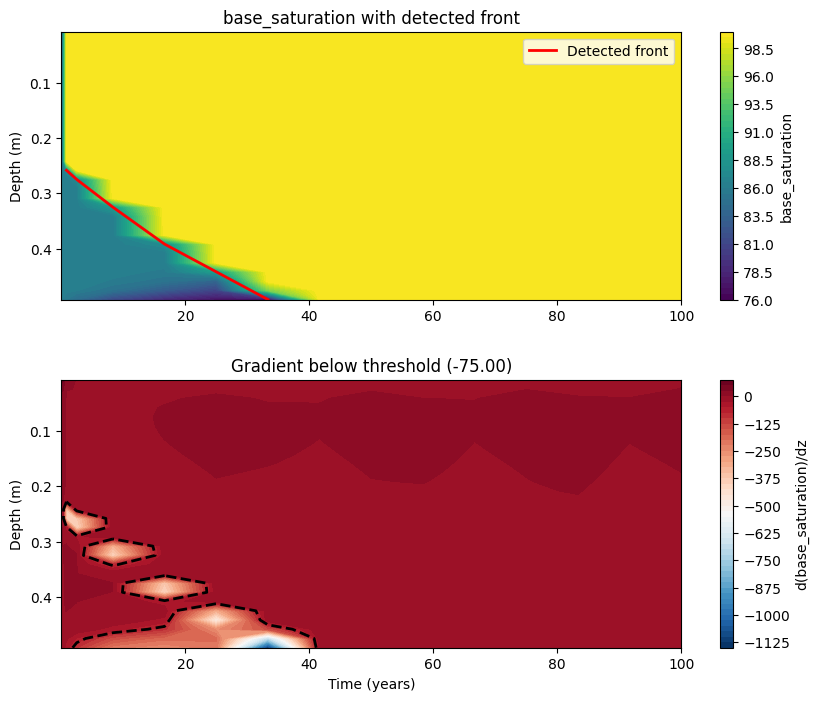

In [14]:
time_vals = pH['time'].values
depth_vals = pH['depth'].values
pH_vals = pH.values
grad_vals = grad.values

# Mask gradient below threshold
grad_masked = np.where(grad_vals < best_thresh, grad_vals, np.nan)

# Create meshgrid for contourf
T, D = np.meshgrid(time_vals, depth_vals)  # shape: (depth, time)

# Transpose data to match meshgrid
pH_plot = pH_vals.T
grad_plot = grad_vals.T  # grad_masked.T

# Create figure with gridspec
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=0.3)

# --- Panel 1: pH heatmap ---
ax1 = fig.add_subplot(gs[0])
cf1 = ax1.contourf(T, D, pH_plot.transpose(), levels=50, cmap='viridis')
fig.colorbar(cf1, ax=ax1, label=thisvar)

# Overlay detected front
ax1.plot(times_out, fronts_out, color='red', lw=2, label='Detected front')
ax1.invert_yaxis()
ax1.set_ylabel('Depth (m)')
ax1.set_title(f'{thisvar} with detected front')
ax1.legend()

# --- Panel 2: Gradient below threshold ---
ax2 = fig.add_subplot(gs[1])
cf2 = ax2.contourf(T, D, grad_plot.transpose(), levels=50, cmap='RdBu_r')
# Overlay contour at best_thresh
cont = ax2.contour(T, D, grad_plot.transpose(), levels=[best_thresh], colors='black', linewidths=2)
fig.colorbar(cf2, ax=ax2, label=f'd({thisvar})/dz')
ax2.invert_yaxis()
ax2.set_xlabel('Time (years)')
ax2.set_ylabel('Depth (m)')
ax2.set_title(f'Gradient below threshold ({best_thresh:.2f})')

plt.show()


# Calculate fronts for all simulations 

In [15]:
# **********************************
# [ USER SETTINGS ]
profname = "adsorbed_percCEC"
varname = "base_saturation"
alpha = 1.
# **********************************
if thisvar == "ph":
    thresholds = np.linspace(-2, -30, 20)
elif thisvar == "base_saturation":
    thresholds = np.linspace(-75, -300, 20)
else:
    print(f"No custom thresholds set for var {thisvar}")
    
dsc = ds_dict[profname]

# --- get indices for all simulations 
loopthrough_dims = ['collapsed_inputs', 'site', 'dustrate_ton_ha_yr']
# get the coordinates for each facet dimension
coord_lists = [dsc.coords[dim].values for dim in loopthrough_dims]
# all combinations of coordinates
coord_combinations = list(itertools.product(*coord_lists))

# --- loop through all cases
prof_ds_dict = {}
grad_ds_dict = {}
res_dict = {
    'iter': [],
    'threshold': [],
    'rate': [],
    'dustrate': [],
    'site': [],
    'collapsed_inputs': []
}
index = 0
for coords in coord_combinations:
    print(f"Solving {index+1}/{len(coord_combinations)}", end='\r', flush=True)
    # name this iter
    namedx = f"iter_{index}"
    # create dict for .sel
    sel_dict = dict(zip(loopthrough_dims, coords))
    # pull out just these data 
    tmpds = dsc[varname].sel(sel_dict)

    # [ run the front detector ]
    grad, best_thresh, times_out, fronts_out = detect_front_from_grad(tmpds, weighted=False, thresholds=thresholds)

    # *******************************************************
    # [ compute the rate of change ]
    # print("Selected threshold for gradient:", best_thresh)
    # compute propagation rate
    # skip if no output (usually means failed run w/ no input)
    if times_out.size == 1:  # then it's None
        index += 1
        continue
    df = pd.DataFrame({'time': times_out, 'depth': fronts_out})
    df['time_float'] = df['time'] - df['time'].iloc[0]
    fit = np.polyfit(df['time_float'], df['depth'], 1)
    # *******************************************************
    # [ fill in the results dict ]
    res_dict['iter'].append(index)
    res_dict['threshold'].append(best_thresh)
    res_dict['rate'].append(fit[0])
    res_dict['dustrate'].append(tmpds.dustrate_ton_ha_yr.values)
    res_dict['site'].append(tmpds.site.values)
    res_dict['collapsed_inputs'].append(tmpds.collapsed_inputs.values)
    # print("Propagation rate:", rate, "m per year")
    grad_ds_dict[namedx] = grad
    prof_ds_dict[namedx] = tmpds

    index += 1

# convert to df and fix the numpy column issue
dfx = pd.DataFrame(res_dict)
# --- omit erroneous rates
dfx = dfx[dfx['rate'] > 1e-3]
# plt.plot(dfx['rate'])
# tmpds
# --- fix site, dustrate and collapsed_inputs
dfx['dustrate'] = dfx['dustrate'].apply(lambda x: x.item())
dfx['collapsed_inputs'] = dfx['collapsed_inputs'].apply(lambda x: x.item())
dfx['site_fixed'] = dfx['site'].apply(lambda x: x.item())

In [ ]:
# # [ SAVE RESULTS ] -----------------------------------------------------------------
# import pickle
# import s3fs

# fs = s3fs.S3FileSystem()  # use anon=True for public buckets
# # --- save results
# savedir = os.path.join(datpath, f"{EXP_SET}_{idx}", "prof_fronts")
# print(f"saving to {savedir}")
# # [ output dataframe ]
# dfx.to_pickle(os.path.join(savedir, f"{profname}-{varname}.pkl"))
# # [ 2d gradients ]
# with fs.open(os.path.join(savedir, f"{varname}-gradient_datasets.pkl"), "wb") as f:
#     pickle.dump(grad_ds_dict, f)
# # [ 2d profiles ]
# with fs.open(os.path.join(savedir, f"{varname}-profile_datasets.pkl"), "wb") as f:
#     pickle.dump(prof_ds_dict, f)

saving to s3://carbonplan-carbon-removal/ew-workflows-data/scepter/postprocessed/lrOAT_noAmnt_cbas_001/prof_fronts


# Read in front data

In [17]:
# ---
this_prof = 'adsorbed_percCEC'
thisvar = 'base_saturation'
# ---
EXP_SETS = [
    "lrOAT", 
    "lrOAT_noAmnt",
    "lrOAT_saRule1",
    "lrOAT_noAmnt_cbas",  
    # "lrOAT_psdbulk",       # [ TO ADD ]
    # "lrOAT_psdfull",       # [ TO ADD ]
    # "lrOAT_cbas",          # [ TO ADD ]
] 


ratename = f"{this_prof}-{thisvar}.pkl"

# --- read in 
maindir = "s3://carbonplan-carbon-removal/ew-workflows-data/scepter/postprocessed/"
idx = "001"
pkl_dict = {}
for EXP_SET in EXP_SETS:
    print(f"reading in: {EXP_SET}")
    readme = os.path.join(maindir, f"{EXP_SET}_{idx}", "prof_fronts", ratename)
    pkl_dict[EXP_SET] = pd.read_pickle(readme)



reading in: lrOAT
reading in: lrOAT_noAmnt
reading in: lrOAT_saRule1
reading in: lrOAT_noAmnt_cbas


## Example from one set of simulations

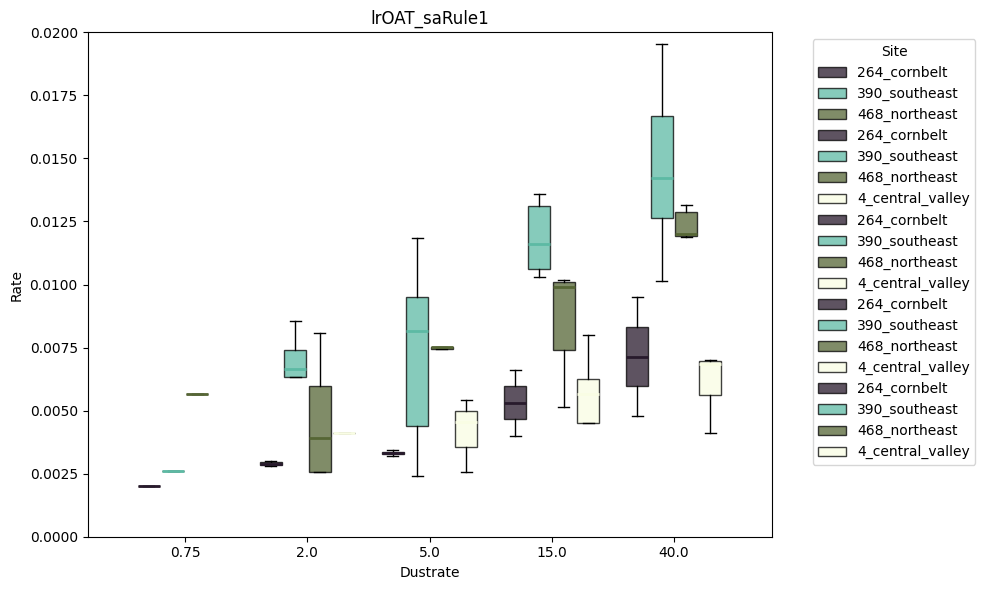

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean.cm as cmo


# *******************************
# [ select data ]
thisdx = 2
dfx = pkl_dict[EXP_SETS[thisdx]]
# *******************************

# Assume df has columns:
# "dustrate", "rate", "site_fixed", "collapsed_inputs"
cmap = cmo.topo  # or "balance", "haline", etc.

# Unique dustrates and sites (sorted for consistent plotting)
dustrates = np.sort(dfx["dustrate"].unique())
sites = np.sort(dfx["site_fixed"].unique())

num_d = len(dustrates)
num_s = len(sites)

# Width of each box group and individual boxes
group_width = 0.8
box_width = group_width / num_s

fig, ax = plt.subplots(figsize=(10, 6))

# --------------------------
# 1. DRAW GROUPED BOXPLOTS
# --------------------------

for i, d in enumerate(dustrates):
    # x-center of the group
    group_center = i  

    for j, site in enumerate(sites):
        # Extract that subset
        subset = dfx[(dfx["dustrate"] == d) & (dfx["site_fixed"] == site)]["rate"]
        if subset.empty:
            continue

        # Compute x-position for this site's box within the group
        x = group_center - group_width/2 + j * box_width + box_width/2

        # Draw boxplot
        bp = ax.boxplot(
            subset,
            positions=[x],
            widths=box_width * 0.9,
            patch_artist=True,
            showfliers=False,
            label=f"{site}"
        )

        # Color the boxes (optional)
        # color = plt.cm.tab10(j % 10)
        color = cmap(j / (len(sites)-1))
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
        # Set median line color
        for median in bp['medians']:
            median.set_color(color)        # <-- horizontal line color
            median.set_linewidth(2)        

# --------------------------
# 2. CONNECT MEANS (OR MEDIANS)
# --------------------------

# for j, site in enumerate(sites):
#     means = []
#     xs = []

#     for i, d in enumerate(dustrates):
#         subset = dfx[(dfx["dustrate"] == d) & (dfx["site_fixed"] == site)]["rate"]
#         if subset.empty:
#             continue

#         means.append(subset.median())  # or subset.median()
#         xs.append(i)

#     ax.plot(xs, means, marker="o", linewidth=2, label=f"{site}")

# --------------------------
# 3. AXIS LABELS & FORMATTING
# --------------------------

ax.set_xticks(range(num_d))
ax.set_xticklabels(dustrates)
ax.set_xlabel("Dustrate")
ax.set_ylabel("Rate")
ax.set_ylim(0, 0.02)
ax.set_title(f"{EXP_SETS[thisdx]}")
ax.legend(title="Site", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


## Repeated in multi-panel form

In [77]:
EXP_SETS[1]

'lrOAT_noAmnt'

In [28]:
sites = np.sort(dfx["site_fixed"].unique())
sites

array(['264_cornbelt', '390_southeast', '468_northeast',
       '4_central_valley'], dtype=object)

/var/folders/2r/w7zcr7vx4p5cr7n4d0b51f4c0000gn/T/ipykernel_53265/393987063.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


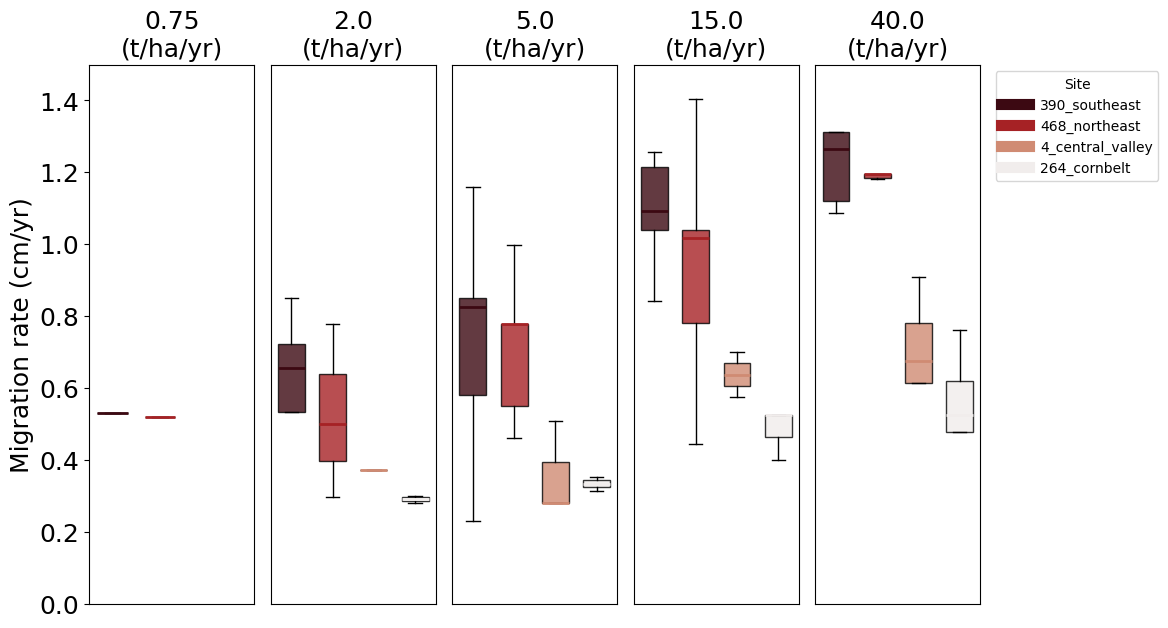

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean.cm as cmo
from matplotlib.gridspec import GridSpec

# *******************************
# [ select data ]
thisdx = 1  # [lroat, lroat_noamnt, lroat_sarule2]
dfx = pkl_dict[EXP_SETS[thisdx]]
dfx['rate_cm_yr'] = dfx['rate'] * 100
# *******************************

# -------------------------------
# aesthetics
cmap = cmo.amp_r
figheight = 7
figwidth_factor = 2.3
barwidths = 0.65
baralpha = 0.8
# axes
ymin, ymax = 0, 1.5
fs_main = 18
fs_xlab = fs_main
fs_ylab = fs_main
fs_ytick = fs_main
fs_title = fs_main
# -------------------------------

# Unique dustrates and sites
dustrates = np.sort(dfx["dustrate"].unique())
sites = np.sort(dfx["site_fixed"].unique())
# set the site order to match the colorbar gradient
sites = ['390_southeast', '468_northeast', '4_central_valley', '264_cornbelt']

num_d = len(dustrates)
num_s = len(sites)

# --------------------------
# 1. SETUP FIGURE + GRIDSPEC
# --------------------------
fig = plt.figure(figsize=(figwidth_factor * num_d, figheight))

# 1 row, num_d columns
gs = GridSpec(1, num_d, figure=fig, wspace=0.1)  # <--- adjust wspace

axes = [fig.add_subplot(gs[0, i]) for i in range(num_d)]

# --------------------------
# 2. DRAW PANELS
# --------------------------

for k, (ax, d) in enumerate(zip(axes, dustrates)):

    positions = np.arange(num_s)

    for j, site in enumerate(sites):
        subset = dfx[(dfx["dustrate"] == d) &
                     (dfx["site_fixed"] == site)]["rate_cm_yr"]

        if subset.empty:
            continue

        bp = ax.boxplot(
            subset,
            positions=[j],
            widths=barwidths,
            patch_artist=True,
            showfliers=False
        )

        color = cmap(j / (num_s - 1))
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(baralpha)
        for median in bp['medians']:
            median.set_color(color)
            median.set_linewidth(2)

    # X-axis formatting
    ax.set_xticks(positions)
    ax.set_xticklabels(sites)
    ax.set_xlabel("", fontsize=fs_xlab)
    ax.tick_params(axis='x', length=0, labelbottom=False)

    # Panel title
    # ax.set_title(f"Dust rate = {d}\n(ton/ha/yr)", fontsize=fs_title)
    ax.set_title(f"{d}\n(t/ha/yr)", fontsize=fs_title)

    # Y axis unified
    ax.set_ylim(ymin, ymax)

    # Remove y-axis ticks/labels for panels 2–N
    if k > 0:
        ax.set_ylabel("")
        ax.set_yticklabels([])
        ax.tick_params(axis='y', length=0)

# First panel gets the y-label
axes[0].set_ylabel("Migration rate (cm/yr)", fontsize=fs_ylab)
axes[0].tick_params(axis='y', labelsize=fs_ytick)

# --------------------------
# 3. OPTIONAL: LEGEND
# --------------------------
legend_handles = [
    plt.Line2D([0], [0], color=cmap(j / (num_s - 1)), lw=8, label=str(site))
    for j, site in enumerate(sites)
]
axes[-1].legend(
    handles=legend_handles,
    title="Site",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## Get difference between simulations

In [23]:
# --- compare directly across conditions 
sites = dfx.site_fixed.unique()
collin = dfx.collapsed_inputs.unique()
dustrates = dfx.dustrate.unique()

dfx_ctrl = pkl_dict['lrOAT_noAmnt']
dfx_fert = pkl_dict['lrOAT']
dfx_sa2 = pkl_dict['lrOAT_saRule1']
dfx_fs = pkl_dict['lrOAT_noAmnt_cbas']

rateEff_fert = []
rateEff_sa2 = []
rateEff_fs = []
ratelist_ctrl = []
ratelist_fert = []
ratelist_sa2 = []
ratelist_fs = []
sitelist = []
colllist = []
dustlist = []

for thissite in sites:
    print(f"solving {thissite}")
    for thiscoll in collin:
        for thisdust in dustrates:
            # update lists
            sitelist.append(thissite)
            colllist.append(thiscoll)
            dustlist.append(thisdust)
            # get rates
            try:
                ctrl_rate = dfx_ctrl[(dfx_ctrl['site'] == thissite) & (dfx_ctrl['collapsed_inputs'] == thiscoll) & (dfx_ctrl['dustrate'] == thisdust)]['rate'].values[0]
            except:
                ctrl_rate = np.nan
            try:
                fert_rate = dfx_fert[(dfx_fert['site'] == thissite) & (dfx_fert['collapsed_inputs'] == thiscoll) & (dfx_fert['dustrate'] == thisdust)]['rate'].values[0]
            except:
                fert_rate = np.nan
            try: 
                sa2_rate = dfx_sa2[(dfx_sa2['site'] == thissite) & (dfx_sa2['collapsed_inputs'] == thiscoll) & (dfx_sa2['dustrate'] == thisdust)]['rate'].values[0]
            except:
                sa2_rate = np.nan
            try: 
                fs_rate = dfx_fs[(dfx_fs['site'] == thissite) & (dfx_fs['collapsed_inputs'] == thiscoll) & (dfx_fs['dustrate'] == thisdust)]['rate'].values[0]
            except:
                fs_rate = np.nan 

            ratelist_ctrl.append(ctrl_rate)
            ratelist_fert.append(fert_rate)
            ratelist_sa2.append(sa2_rate)
            ratelist_fs.append(fs_rate)
            # get effects
            rateEff_fert.append(fert_rate - ctrl_rate)
            rateEff_sa2.append(sa2_rate - ctrl_rate)
            rateEff_fs.append(fs_rate - ctrl_rate)

# bring together
outdict = {
    'site': sitelist,
    'collapsed_inputs': colllist,
    'dustrate': dustlist,
    'ctrl_rate': ratelist_ctrl,
    'fert_rate': ratelist_fert,
    'sa2_rate': ratelist_sa2,
    'fs_rate': ratelist_fs,
    'fert_effect': rateEff_fert,
    'sa2_effect': rateEff_sa2,
    'fs_effect': rateEff_fs,
}


solving 264_cornbelt
solving 390_southeast
solving 468_northeast
solving 4_central_valley


In [25]:
outdf = pd.DataFrame(outdict)

outdf

,site,collapsed_inputs,dustrate,ctrl_rate,fert_rate,sa2_rate,fs_rate,fert_effect,sa2_effect,fs_effect
0,264_cornbelt,dustrad=10 | secondary_min_rule=sld_track | po...,2.00,0.003000,0.003000,0.003000,NaN,-1.286451e-12,0.000000,NaN
1,264_cornbelt,dustrad=10 | secondary_min_rule=sld_track | po...,5.00,0.003533,0.003467,0.003433,0.003891,-6.666667e-05,-0.000100,0.000358
2,264_cornbelt,dustrad=10 | secondary_min_rule=sld_track | po...,15.00,0.005257,0.004743,0.006623,0.005721,-5.142857e-04,0.001366,0.000464
3,264_cornbelt,dustrad=10 | secondary_min_rule=sld_track | po...,40.00,0.007600,0.007143,0.009488,0.007195,-4.571429e-04,0.001888,-0.000405
4,264_cornbelt,dustrad=10 | secondary_min_rule=sld_track | po...,0.75,NaN,NaN,0.002000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
115,4_central_valley,dustrad=75 | secondary_min_rule=sld_track | po...,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,4_central_valley,dustrad=75 | secondary_min_rule=sld_track | po...,5.00,NaN,NaN,0.004533,0.002287,NaN,NaN,NaN
117,4_central_valley,dustrad=75 | secondary_min_rule=sld_track | po...,15.00,NaN,0.005115,0.001167,0.006041,NaN,NaN,NaN
118,4_central_valley,dustrad=75 | secondary_min_rule=sld_track | po...,40.00,0.007381,0.006905,0.004127,0.007780,-4.761905e-04,-0.003254,0.000399


## Plot PDFs of the differences

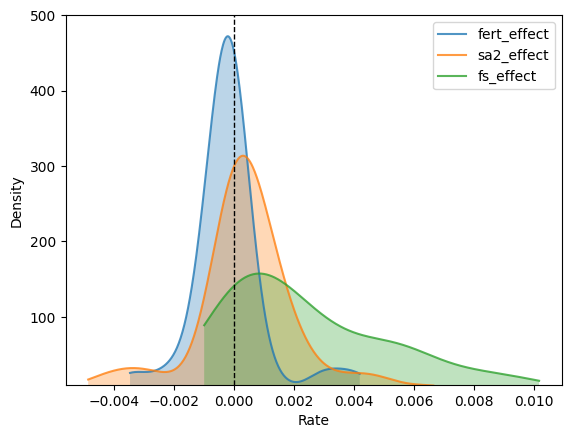

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

cols = ['fert_effect', 'sa2_effect', 'fs_effect']

fig, ax = plt.subplots()

for col in cols:
    x = outdf[col].dropna().values
    kde = gaussian_kde(x)
    xs = np.linspace(x.min(), x.max(), 500)
    ax.plot(xs, kde(xs), label=col, alpha=0.78)
    ax.fill_between(xs, kde(xs), alpha=0.3)  # 
ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("Rate")
ax.set_ylabel("Density")
ax.set_ylim(10,500)
ax.legend()
plt.show()

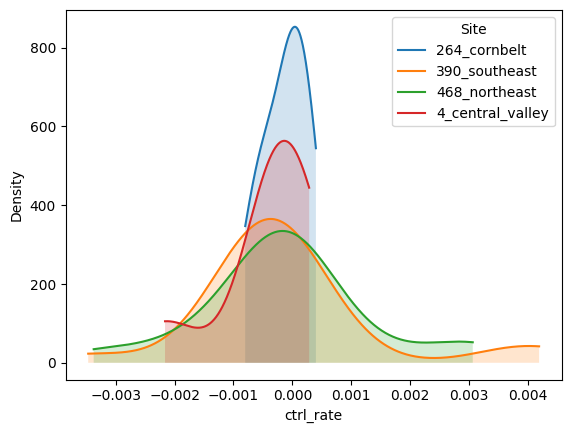

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

bysite_column = "fert_effect"

fig, ax = plt.subplots()

for site, subdf in outdf.groupby("site"):
    x = subdf[bysite_column].dropna().values
    if len(x) < 2:
        continue  # KDE needs at least 2 points

    kde = gaussian_kde(x)
    xs = np.linspace(x.min(), x.max(), 500)
    ys = kde(xs)

    ax.plot(xs, ys, label=site)
    ax.fill_between(xs, ys, alpha=0.2)

ax.set_xlabel("ctrl_rate")
ax.set_ylabel("Density")
ax.legend(title="Site")
# ax.set_xlim(0,0.02)
plt.show()
